# A2: Inference and uncertainty in a penguin body-mass comparison
Author: xuhongbo · Student ID: 202618018629048 · Data Science


## Abstract

This study estimates the male-minus-female mean body-mass difference among Adelie penguins and examines how sampling assumptions affect uncertainty. The frozen dataset provides 73 male and 73 female complete records. A Welch analysis estimates a difference of 674.7 g, with a 95% interval of [573.0, 776.3] g. A 10,000-replicate within-group percentile bootstrap gives [577.4, 774.7] g. The predefined minimum meaningful difference is 200 g, used as a teaching threshold rather than a biological standard.

Using 5,000 repetitions per scenario, normal-population simulations compare the sampling distribution with its known form and vary sample size, noise, and effect. Baseline Welch interval coverage is 94.9%. At a true difference of 200 g and a within-group standard deviation of 400 g, power rises from 35.1% at 20 observations per group to 88.1% at 80.

A dependence counterexample holds marginal variance fixed while correlating records within clusters. With five records per cluster and correlation 0.6, the nominal 5% test has a false-positive rate of 29.5% when dependence is ignored, versus 5.1% when independent cluster means are analyzed. Corresponding interval coverage is 70.5% and 94.9%. These results distinguish larger nominal samples from more independent information. Real-data conclusions remain conditional on sampling and missingness assumptions and do not establish causality.


## 1. Question and analysis protocol

How large is the difference in mean body mass between male and female Adelie penguins,
and how sensitive is uncertainty quantification to sample size, noise, and independence?
The estimand is **male minus female population mean mass**, in grams, for Adelie penguins
in the sampled setting under a representative-sampling assumption. The observed contrast
is descriptive of the available complete records. Generalizing it requires assumptions
about selection, missingness, and dependence that the table alone cannot establish.

The primary hypotheses are H0: difference = 0 versus H1: difference != 0, with a two-sided
significance level of 0.05. The primary method is a Welch t interval/test; an independently
resampled, within-sex percentile bootstrap is a sensitivity comparison. The **minimum
meaningful absolute difference is 200 g**, a teaching threshold chosen for this exercise,
not an established biological criterion. Rejecting a zero-difference null and establishing
that a difference exceeds 200 g are different statements; the interval will be compared
with both zero and the threshold.

`protocol.json` fixes these choices and the simulation grid before this project's data
analysis. This is a documented analysis plan, not an external preregistration. Prior discussion
identified this dataset and question, so the analysis is not described as blind discovery.
No choice of species, threshold, or power scenario is based on the observed p-value.

### Code 01: environment and protocol
按 01 至 09 从头执行。每次运行保留独立结果目录。所有模拟都有单独种子。


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import os, sys, json, hashlib, platform, subprocess
BASE = Path.cwd()
if not (BASE / "protocol.json").exists():
    raise FileNotFoundError("Start the kernel in DS-A2.")
for name in ["tmp", "matplotlib"]:
    (BASE / ".runtime" / name).mkdir(parents=True, exist_ok=True)
os.environ["TMPDIR"] = str(BASE / ".runtime/tmp")
os.environ["MPLCONFIGDIR"] = str(BASE / ".runtime/matplotlib")
import tempfile
tempfile.tempdir = os.environ["TMPDIR"]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown
from importlib.metadata import version
P = json.loads((BASE / "protocol.json").read_text())
R, ALPHA, MME = P["simulation_replicates"], P["alpha"], P["meaningful_difference_g"]
OUT = BASE / "results" / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
OUT.mkdir(parents=True)
packages = {p: version(p) for p in ["numpy", "pandas", "scipy", "matplotlib", "ipython", "ipykernel", "nbformat", "nbconvert"]}
(OUT / "environment.json").write_text(json.dumps({"python": sys.version, "executable": sys.executable, "platform": platform.platform(), "packages": packages}, indent=2))
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True)
(OUT / "requirements-lock.txt").write_text(freeze.stdout)
if freeze.returncode:
    (OUT / "environment-error.txt").write_text(freeze.stderr)
    raise RuntimeError("Dependency recording failed.")
(OUT / "protocol.json").write_text(json.dumps(P, indent=2))
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 10})
print("Result directory:", OUT)
display(pd.Series(packages, name="version").to_frame())
print("Predefined simulation grid:", P["power"])


Result directory: /data2/xuhongbo/DS_HW/DS-A2/results/20261008T140046_499927Z


,version
numpy,1.26.4
pandas,2.3.3
scipy,1.15.3
matplotlib,3.10.8
ipython,8.39.0
ipykernel,7.3.0
nbformat,5.11.1
nbconvert,7.17.1


Predefined simulation grid: {'n_per_group': [10, 20, 40, 80, 160], 'sigma_g': [250, 400, 600], 'delta_g': [0, 100, 200, 400]}


## 2. Data and exclusions

The data were collected by Kristen Gorman and Palmer Station LTER. This project uses the
upstream simplified CSV from [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/),
which documents 344 penguins and a CC0 data license. The
[Kaggle mirror](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data)
was the discovery entry point; we did not download a Kaggle archive or assume byte identity.
The exact upstream commit, URL, download time and hash are in `data/raw/manifest.json`.
Attribution: Horst, Hill and Gorman (2020), *palmerpenguins*, DOI 10.5281/zenodo.3960218.

Select Adelie and exclude only records lacking mass or a male/female label. Missing values in
unrelated measurements do not justify discarding a usable mass record. Sex is not a randomized
treatment, and this comparison does not estimate a causal effect. Sampling across islands
and years may create heterogeneity or dependence; the inference below is conditional on its
stated sampling assumptions.

### Code 02: frozen data and group summaries


In [2]:
manifest = json.loads((BASE / "data/raw/manifest.json").read_text())
raw = (BASE / "data/raw/penguins.csv").read_bytes()
assert hashlib.sha256(raw).hexdigest() == manifest["sha256"], "Data bytes changed."
(OUT / "source_manifest.json").write_text(json.dumps(manifest, indent=2))
df = pd.read_csv(BASE / "data/raw/penguins.csv")
subset = df.loc[df.species.eq(P["species"])].copy()
use = subset.body_mass_g.notna() & subset.sex.isin(["male", "female"])
excluded = subset.loc[~use]
data = subset.loc[use]
excluded.to_csv(OUT / "excluded_records.csv", index_label="source_row")
data.to_csv(OUT / "analysis_records.csv", index_label="source_row")
male = data.loc[data.sex.eq("male"), "body_mass_g"].to_numpy()
female = data.loc[data.sex.eq("female"), "body_mass_g"].to_numpy()
groups = data.groupby("sex").body_mass_g.agg(["count", "mean", "std", "min", "max"])
groups.to_csv(OUT / "group_summary.csv")
print("SHA-256:", manifest["sha256"])
print(f"Original={len(df)}, Adelie={len(subset)}, excluded={len(excluded)}, analyzed={len(data)}")
display(groups.round(2))
display(data.groupby(["island", "year", "sex"]).size().unstack("sex", fill_value=0))


SHA-256: f204db2c753b0937caac3cb35258562c14f073e4bbc76be24b4c51ce22767a93
Original=344, Adelie=152, excluded=6, analyzed=146


,count,mean,std,min,max
sex,,,,,
female,73,3368.84,269.38,2850.0,3900.0
male,73,4043.49,346.81,3325.0,4775.0


sex             female  male
island    year              
Biscoe    2007       5     5
          2008       9     9
          2009       8     8
Dream     2007       9    10
          2008       8     8
          2009      10    10
Torgersen 2007       8     7
          2008       8     8
          2009       8     8

## 3. Method note: effect, interval, and test

For independent group samples, let `d = mean(male) - mean(female)`,
`a = variance(male)/n_male`, and `b = variance(female)/n_female`, using sample variances.
Then `SE = sqrt(a+b)` and the Welch-Satterthwaite degrees of freedom are
`nu = (a+b)^2 / [a^2/(n_male-1) + b^2/(n_female-1)]`.
The interval is `d +/- t_(1-alpha/2, nu) * SE`; the two-sided p-value uses `d/SE`.

The variance sum follows from independence between groups. Welch allows unequal variances,
but still needs independent sampling and suitable behavior of sample means. Its t approximation
is not an exact finite-sample guarantee for arbitrary populations. See the
[SciPy Welch-test documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html).

Bootstrap resampling draws each sex separately, preserving its original sample size.
The 2.5th and 97.5th percentiles of 10,000 resampled differences give a sensitivity interval.
This also assumes independent observations within groups; bootstrap is not a remedy for
unmodeled dependence. Simulations below evaluate the primary Welch procedure rather than
claiming that the bootstrap interval has been calibrated in every scenario.

### Code 03: reusable inference and simulation summaries


In [3]:
def welch(x, y):
    nx, ny = x.shape[-1], y.shape[-1]
    d = x.mean(axis=-1) - y.mean(axis=-1)
    a, b = x.var(axis=-1, ddof=1) / nx, y.var(axis=-1, ddof=1) / ny
    se = np.sqrt(a + b)
    nu = (a + b)**2 / (a*a/(nx-1) + b*b/(ny-1))
    half = stats.t.ppf(1 - ALPHA/2, nu) * se
    p = 2 * stats.t.sf(np.abs(d / se), nu)
    return pd.DataFrame({"estimate": np.atleast_1d(d), "lower": np.atleast_1d(d-half),
                         "upper": np.atleast_1d(d+half), "p": np.atleast_1d(p)})

def summarize_trials(trials, truth):
    reject = (trials.p < ALPHA).mean()
    coverage = ((trials.lower <= truth) & (truth <= trials.upper)).mean()
    return {"rejection_rate": reject, "rejection_mcse": np.sqrt(reject*(1-reject)/len(trials)),
            "coverage": coverage, "coverage_mcse": np.sqrt(coverage*(1-coverage)/len(trials)),
            "mean_width": (trials.upper-trials.lower).mean()}

print("Welch inference uses sample variances and a two-sided test.")
print("Monte Carlo SE describes simulation error, not uncertainty about the real penguin population.")


Welch inference uses sample variances and a two-sided test.
Monte Carlo SE describes simulation error, not uncertainty about the real penguin population.


### Code 04: observed effect and interval figure
The Welch interval is the primary result. Agreement with Bootstrap is useful, but does not
validate shared assumptions. The figure also marks zero and the predefined 200 g threshold.


,method,estimate_g,lower_g,upper_g
0,Welch (primary),674.66,573.01,776.30
1,Percentile bootstrap,674.66,577.40,774.66


Welch two-sided p-value: 6.402319748031793e-26
Primary interval entirely above 200 g: True


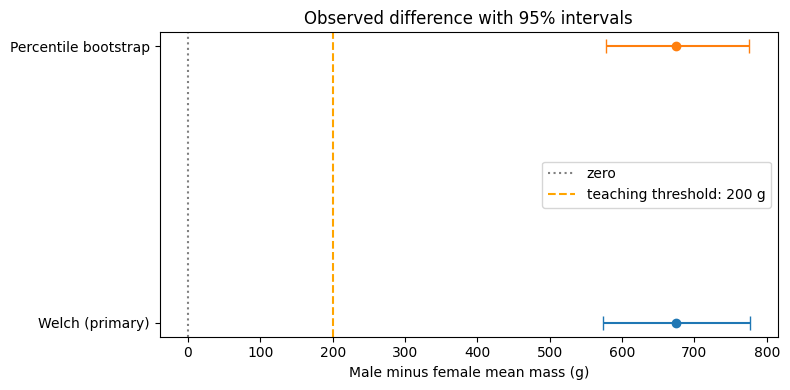

In [4]:
observed = welch(male, female).iloc[0]
reference = stats.ttest_ind(male, female, equal_var=False)
assert np.isclose(observed.p, reference.pvalue, rtol=1e-10)
ref_ci = reference.confidence_interval(confidence_level=1-ALPHA)
assert np.allclose([observed.lower, observed.upper], [ref_ci.low, ref_ci.high])
rng = np.random.default_rng(P["seeds"]["bootstrap"])
B = P["bootstrap_replicates"]
boot = rng.choice(male, size=(B, len(male))).mean(axis=1) - rng.choice(female, size=(B, len(female))).mean(axis=1)
boot_ci = np.quantile(boot, [ALPHA/2, 1-ALPHA/2])
np.save(OUT / "bootstrap_differences.npy", boot)
intervals = pd.DataFrame({"method": ["Welch (primary)", "Percentile bootstrap"],
    "estimate_g": [observed.estimate]*2, "lower_g": [observed.lower, boot_ci[0]],
    "upper_g": [observed.upper, boot_ci[1]]})
intervals.to_csv(OUT / "observed_intervals.csv", index=False)
display(intervals.round(2))
print("Welch two-sided p-value:", observed.p)
print("Primary interval entirely above 200 g:", bool(observed.lower > MME))
fig, ax = plt.subplots()
for i, row in intervals.iterrows():
    ax.errorbar(row.estimate_g, i, xerr=[[row.estimate_g-row.lower_g], [row.upper_g-row.estimate_g]], fmt="o", capsize=5)
ax.axvline(0, color="gray", linestyle=":", label="zero")
ax.axvline(MME, color="orange", linestyle="--", label="teaching threshold: 200 g")
ax.set(yticks=[0, 1], yticklabels=intervals.method, xlabel="Male minus female mean mass (g)", title="Observed difference with 95% intervals")
ax.legend(); fig.tight_layout(); fig.savefig(OUT / "effect_intervals.png", bbox_inches="tight"); plt.show()


## 4. Sampling distribution with a known truth

For this teaching simulation, female and male masses are independent normal draws with means
3500 g and `3500 + delta` g, and a common standard deviation `sigma`. The baseline fixes
`delta=200`, `sigma=400`, and 40 observations per group. These are planned simulation values,
not fitted population truths. Negative masses are theoretically possible under this normal
approximation; it is a local model for a mean-comparison exercise, not a biological generator.

The difference of sample means is normal here, with mean `delta` and standard deviation
`sqrt(2*sigma^2/n)`. Comparing that known curve with simulation checks both the code and the
meaning of sampling variability. Coverage is the fraction of intervals that include the
known truth across repetitions, not a posterior probability for a fixed observed interval.

### Code 05: repeated sampling and coverage


,value
rejection_rate,0.602200
rejection_mcse,0.006922
coverage,0.949400
coverage_mcse,0.003100
mean_width,354.612685
empirical_mean,200.045151
empirical_sd,90.102657
theoretical_mean,200.000000
theoretical_sd,89.442719


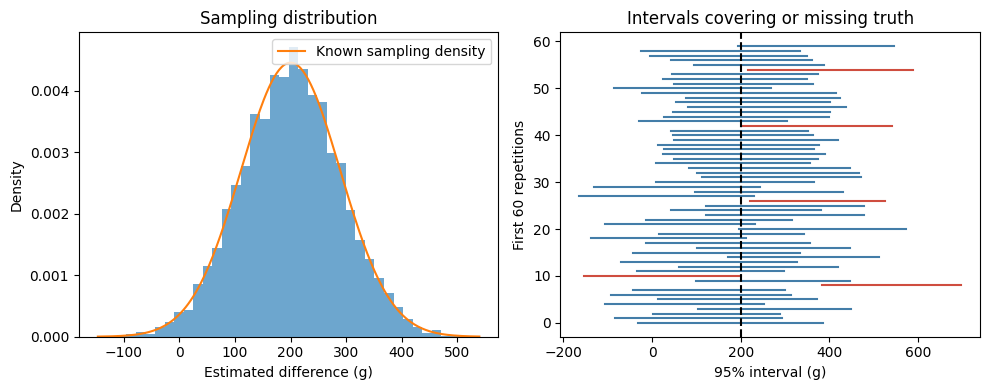

In [5]:
s = P["sampling"]
n, sigma, delta = s["n_per_group"], s["sigma_g"], s["delta_g"]
rng = np.random.default_rng(P["seeds"]["sampling"])
x = rng.normal(3500 + delta, sigma, size=(R, n))
y = rng.normal(3500, sigma, size=(R, n))
sampling = welch(x, y)
sampling.to_csv(OUT / "sampling_replicates.csv", index=False)
sampling_summary = summarize_trials(sampling, delta)
sampling_summary.update({"empirical_mean": sampling.estimate.mean(), "empirical_sd": sampling.estimate.std(),
                         "theoretical_mean": delta, "theoretical_sd": np.sqrt(2*sigma**2/n)})
display(pd.Series(sampling_summary, name="value").to_frame())
(OUT / "sampling_summary.json").write_text(json.dumps(sampling_summary, indent=2))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(sampling.estimate, bins=40, density=True, alpha=.65)
grid = np.linspace(sampling.estimate.min(), sampling.estimate.max(), 300)
axes[0].plot(grid, stats.norm.pdf(grid, delta, np.sqrt(2*sigma**2/n)), label="Known sampling density")
axes[0].set(xlabel="Estimated difference (g)", ylabel="Density", title="Sampling distribution")
axes[0].legend()
for i, row in sampling.head(60).iterrows():
    color = "#437da8" if row.lower <= delta <= row.upper else "#cf4d3f"
    axes[1].plot([row.lower, row.upper], [i, i], color=color)
axes[1].axvline(delta, color="black", linestyle="--")
axes[1].set(xlabel="95% interval (g)", ylabel="First 60 repetitions", title="Intervals covering or missing truth")
fig.tight_layout(); fig.savefig(OUT / "sampling_distribution.png", bbox_inches="tight"); plt.show()


## 5. Power: sample size, noise, and effect

The grid changes one of `n`, `sigma`, and `delta` while holding the others fixed for comparison.
Each of its 60 scenarios has 5,000 independent repetitions. At `delta=0`, rejection frequency
is the Type I error rate; at nonzero delta, it is power. This is prospective, model-based power,
not an observed-power calculation derived from the real-data p-value.

Every rate is accompanied by Monte Carlo standard error, `sqrt(p_hat*(1-p_hat)/R)`.
The plot's error bars show approximately two Monte Carlo standard errors. Small departures
from monotonicity should be judged against this simulation noise, not concealed or rerun
until a preferred result appears.

### Code 06: full power grid and raw replicate results


,n_per_group,delta_g,rejection_rate,rejection_mcse,coverage
4,10,0,0.0504,0.0031,0.9496
5,10,100,0.0798,0.0038,0.9534
6,10,200,0.1756,0.0054,0.9506
7,10,400,0.5664,0.0070,0.9464
16,20,0,0.0524,0.0032,0.9476
17,20,100,0.1184,0.0046,0.9522
18,20,200,0.3512,0.0068,0.9468
19,20,400,0.8674,0.0048,0.9504
28,40,0,0.0486,0.0030,0.9514
29,40,100,0.1944,0.0056,0.9500


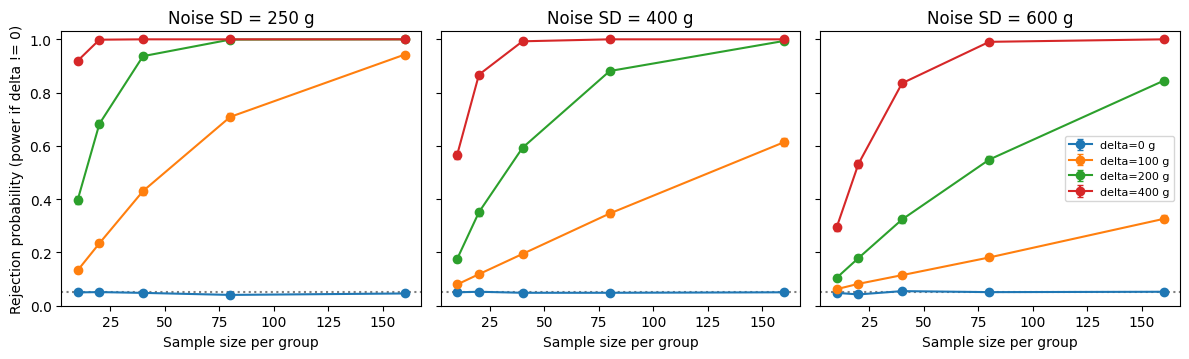

In [6]:
from itertools import product
scenarios = list(product(P["power"]["n_per_group"], P["power"]["sigma_g"], P["power"]["delta_g"]))
streams = np.random.SeedSequence(P["seeds"]["power"]).spawn(len(scenarios))
power_rows, power_raw = [], {}
for sid, ((n, sigma, delta), stream) in enumerate(zip(scenarios, streams)):
    rng = np.random.default_rng(stream)
    trials = welch(rng.normal(3500+delta, sigma, (R, n)), rng.normal(3500, sigma, (R, n)))
    power_rows.append({"scenario": sid, "n_per_group": n, "sigma_g": sigma, "delta_g": delta, **summarize_trials(trials, delta)})
    power_raw[f"scenario_{sid:02d}"] = trials.to_numpy()
power = pd.DataFrame(power_rows)
power.to_csv(OUT / "power_grid.csv", index=False)
np.savez_compressed(OUT / "power_replicates.npz", **power_raw)
(OUT / "replicate_columns.json").write_text(json.dumps(trials.columns.tolist()))
display(power.loc[power.sigma_g.eq(400), ["n_per_group", "delta_g", "rejection_rate", "rejection_mcse", "coverage"]].round(4))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharey=True)
for ax, sigma in zip(axes, P["power"]["sigma_g"]):
    for delta in P["power"]["delta_g"]:
        part = power.loc[power.sigma_g.eq(sigma) & power.delta_g.eq(delta)]
        ax.errorbar(part.n_per_group, part.rejection_rate, yerr=2*part.rejection_mcse,
                    marker="o", capsize=2, label=f"delta={delta} g")
    ax.axhline(ALPHA, color="gray", linestyle=":")
    ax.set(title=f"Noise SD = {sigma} g", xlabel="Sample size per group", ylim=(0, 1.03))
axes[0].set_ylabel("Rejection probability (power if delta != 0)")
axes[-1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "power_curves.png", bbox_inches="tight"); plt.show()


## 6. Counterexample: correlated records

The baseline treated observations as independent. Here each sex has 20 independent clusters,
with 5 observations in each cluster. Clusters are independent between sexes as well. A record
is generated as `group_mean + cluster_effect + individual_error`. The cluster-effect variance
is `rho*sigma^2` and the error variance is `(1-rho)*sigma^2`. Thus marginal variance stays
`sigma^2`; the only changed assumption is within-cluster correlation.

The variance of a group mean increases by the design effect `1+(m-1)*rho`. For `m=5` and
`rho=0.6`, that factor is 3.4, even though the nominal sample size is still 100 per sex.
Ignoring dependence can therefore underestimate uncertainty. The counterexample does not
claim that the real penguin records have this correlation structure.

Compare a naive Welch analysis of all 100 records per sex with Welch analysis of the 20
independent cluster means. Equal cluster sizes make both approaches estimate the same mean
contrast, while the latter uses the correct independent sampling units in this model.
The correction would need reconsideration for unequal or informative cluster sizes.
Both the null and 200 g alternative are evaluated; rho=0 is the negative control.

### Code 07: false positives, coverage, and cluster correction


,rho,delta_g,method,rejection_rate,rejection_mcse,coverage,coverage_mcse
0,0.0,0,naive records,0.0496,0.0031,0.9504,0.0031
1,0.0,0,cluster means,0.0478,0.0030,0.9522,0.0030
2,0.0,200,naive records,0.9454,0.0032,0.9504,0.0031
3,0.0,200,cluster means,0.9358,0.0035,0.9496,0.0031
4,0.3,0,naive records,0.1906,0.0056,0.8094,0.0056
5,0.3,0,cluster means,0.0502,0.0031,0.9498,0.0031
6,0.3,200,naive records,0.8486,0.0051,0.8018,0.0056
7,0.3,200,cluster means,0.6454,0.0068,0.9522,0.0030
8,0.6,0,naive records,0.2950,0.0064,0.7050,0.0064
9,0.6,0,cluster means,0.0512,0.0031,0.9488,0.0031


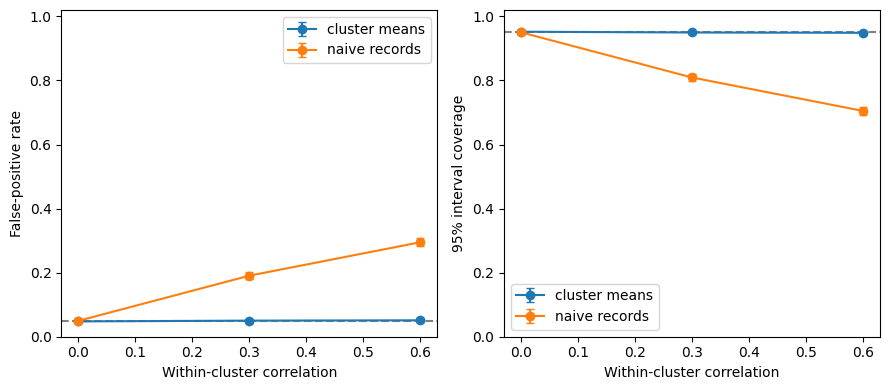

In [7]:
c = P["cluster"]
k, m, sigma = c["clusters_per_group"], c["records_per_cluster"], c["sigma_g"]
cluster_scenarios = list(product(c["rho"], c["delta_g"]))
streams = np.random.SeedSequence(P["seeds"]["cluster"]).spawn(len(cluster_scenarios))
cluster_rows, cluster_raw = [], {}
for sid, ((rho, delta), stream) in enumerate(zip(cluster_scenarios, streams)):
    rng = np.random.default_rng(stream)
    def generate(mu):
        shared = rng.normal(0, sigma*np.sqrt(rho), (R, k, 1))
        individual = rng.normal(0, sigma*np.sqrt(1-rho), (R, k, m))
        return mu + shared + individual
    x, y = generate(3500+delta), generate(3500)
    for method, xx, yy in [("naive records", x.reshape(R, -1), y.reshape(R, -1)),
                           ("cluster means", x.mean(axis=2), y.mean(axis=2))]:
        trials = welch(xx, yy)
        cluster_rows.append({"scenario": sid, "rho": rho, "delta_g": delta, "method": method,
                             "design_effect": 1+(m-1)*rho, **summarize_trials(trials, delta)})
        cluster_raw[f"scenario_{sid:02d}_{method.replace(' ', '_')}"] = trials.to_numpy()
cluster = pd.DataFrame(cluster_rows)
cluster.to_csv(OUT / "cluster_summary.csv", index=False)
np.savez_compressed(OUT / "cluster_replicates.npz", **cluster_raw)
display(cluster[["rho", "delta_g", "method", "rejection_rate", "rejection_mcse", "coverage", "coverage_mcse"]].round(4))
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for method, part in cluster.loc[cluster.delta_g.eq(0)].groupby("method"):
    axes[0].errorbar(part.rho, part.rejection_rate, yerr=2*part.rejection_mcse, marker="o", capsize=3, label=method)
    axes[1].errorbar(part.rho, part.coverage, yerr=2*part.coverage_mcse, marker="o", capsize=3, label=method)
for ax, target, ylabel in zip(axes, [ALPHA, 1-ALPHA], ["False-positive rate", "95% interval coverage"]):
    ax.axhline(target, color="gray", linestyle="--")
    ax.set(xlabel="Within-cluster correlation", ylabel=ylabel, ylim=(0, 1.02))
    ax.legend()
fig.tight_layout(); fig.savefig(OUT / "dependence_counterexample.png", bbox_inches="tight"); plt.show()


## 7. Results and interpretation

The observed interval concerns uncertainty under the real-data analysis assumptions. The
simulation curves concern deliberately specified populations and do not measure prediction
accuracy on penguins. A high rejection rate under the null is a failure of calibration, not
useful power. Any apparent power advantage from ignoring dependence must be read alongside
false-positive rates and interval coverage.

An interval above the 200 g teaching threshold supports a difference exceeding that threshold
only under the model and sampling assumptions. Neither a small p-value nor agreement between
two intervals establishes representative sampling, independent records, or a causal effect.
The numerical summary below reports all planned scenarios through the saved tables; it does
not select only settings that favor the method.

### Code 08: result summary and abstract from actual execution
This cell writes the abstract for this run. The export script places it at the beginning of
the saved notebook and report after checking that all code cells were executed in order.


In [8]:
def power_at(n, sigma, delta):
    return float(power.loc[power.n_per_group.eq(n) & power.sigma_g.eq(sigma) & power.delta_g.eq(delta), "rejection_rate"].iloc[0])
null_cluster = cluster.loc[cluster.rho.eq(.6) & cluster.delta_g.eq(0)].set_index("method")
summary = {"n_male": len(male), "n_female": len(female), "excluded": len(excluded),
    "difference_g": float(observed.estimate), "welch_lower_g": float(observed.lower), "welch_upper_g": float(observed.upper),
    "welch_p": float(observed.p), "bootstrap_lower_g": float(boot_ci[0]), "bootstrap_upper_g": float(boot_ci[1]),
    "sampling_coverage": sampling_summary["coverage"], "sampling_coverage_mcse": sampling_summary["coverage_mcse"],
    "power_n20": power_at(20, 400, 200), "power_n80": power_at(80, 400, 200),
    "naive_fpr_rho06": float(null_cluster.loc["naive records", "rejection_rate"]),
    "corrected_fpr_rho06": float(null_cluster.loc["cluster means", "rejection_rate"]),
    "naive_coverage_rho06": float(null_cluster.loc["naive records", "coverage"]),
    "corrected_coverage_rho06": float(null_cluster.loc["cluster means", "coverage"])}
(OUT / "summary.json").write_text(json.dumps(summary, indent=2))
abstract = f"""This study estimates the male-minus-female mean body-mass difference among Adelie penguins and examines how sampling assumptions affect uncertainty. The frozen dataset provides {len(male)} male and {len(female)} female complete records. A Welch analysis estimates a difference of {observed.estimate:.1f} g, with a 95% interval of [{observed.lower:.1f}, {observed.upper:.1f}] g. A 10,000-replicate within-group percentile bootstrap gives [{boot_ci[0]:.1f}, {boot_ci[1]:.1f}] g. The predefined minimum meaningful difference is 200 g, used as a teaching threshold rather than a biological standard.

Using 5,000 repetitions per scenario, normal-population simulations compare the sampling distribution with its known form and vary sample size, noise, and effect. Baseline Welch interval coverage is {sampling_summary['coverage']:.1%}. At a true difference of 200 g and a within-group standard deviation of 400 g, power rises from {summary['power_n20']:.1%} at 20 observations per group to {summary['power_n80']:.1%} at 80.

A dependence counterexample holds marginal variance fixed while correlating records within clusters. With five records per cluster and correlation 0.6, the nominal 5% test has a false-positive rate of {summary['naive_fpr_rho06']:.1%} when dependence is ignored, versus {summary['corrected_fpr_rho06']:.1%} when independent cluster means are analyzed. Corresponding interval coverage is {summary['naive_coverage_rho06']:.1%} and {summary['corrected_coverage_rho06']:.1%}. These results distinguish larger nominal samples from more independent information. Real-data conclusions remain conditional on sampling and missingness assumptions and do not establish causality."""
assert 150 <= len(abstract.split()) <= 300
(OUT / "ABSTRACT.md").write_text("## Abstract\n\n" + abstract + "\n")
(OUT / "submission_summary.txt").write_text(abstract + "\n")
display(pd.Series(summary, name="result").to_frame())
print("Abstract words:", len(abstract.split()))


,result
n_male,7.300000e+01
n_female,7.300000e+01
excluded,6.000000e+00
difference_g,6.746575e+02
welch_lower_g,5.730139e+02
welch_upper_g,7.763012e+02
welch_p,6.402320e-26
bootstrap_lower_g,5.773973e+02
bootstrap_upper_g,7.746575e+02
sampling_coverage,9.494000e-01


Abstract words: 202


## 8. AI use, independent verification, and reproduction

The analysis plan, data bytes, replicate outputs, environment, and figures are saved with the
run. Simulated observations are explicitly synthetic; they are not additional measured penguins.
The raw replicate files use columns `estimate, lower, upper, p`; their scenario IDs map to
`power_grid.csv` and `cluster_summary.csv`. Independent RNG streams make scenario replication
possible without relying on notebook execution history.

Assistant checks compare the manual Welch implementation with SciPy. This does not count as
the student's independent verification. Complete the personal entries in `AI_USE_LOG.md`
and the author line before submission, then rerun the last cell and export again.

### Code 09: verification log and completed run marker


In [9]:
log = (BASE / "AI_USE_LOG.md").read_text()
display(Markdown(log))
(OUT / "AI_USE_LOG.md").write_text(log)
(OUT / "completed.json").write_text(json.dumps({"completed_utc": datetime.now(timezone.utc).isoformat(),
    "protocol_sha256": hashlib.sha256((BASE / "protocol.json").read_bytes()).hexdigest(),
    "data_sha256": manifest["sha256"], "personal_verification": "See AI_USE_LOG.md"}, indent=2))
print("RESULT_DIR:", OUT.relative_to(BASE).as_posix())
print("Save the notebook, then run export_report.py to refresh the opening abstract and export.")


# AI use and personal verification

Codex drafted the protocol, code, method explanations, and report structure after a ChatGPT
conversation helped select the dataset. The human requested an opening abstract with actual
experimental results. Abstract numbers are populated from the saved run, not invented.

| Suggestion or choice | Decision and reason | Verification status |
|---|---|---|
| Restrict analysis to one species and one outcome | Accepted: Adelie body mass keeps the comparison focused | Student checked the original documentation on 2026-10-08; see section 1 |
| Use a 200 g meaningful difference | Explicit teaching assumption; not claimed as a biological standard | Teaching threshold acknowledged; see section 5 |
| Compare Welch and within-group bootstrap intervals | Accepted; both require independence and suitable sampling | Assistant code compares Welch output with SciPy |
| Compute power from the observed effect | Not used; effect/noise/sample-size grids were fixed separately | Protocol file and simulated truth are inspectable |
| Simulate correlated records | Accepted to isolate an independence violation while preserving marginal variance | Model and design-effect derivation are in the notebook |
| Treat significant sex differences as causal | Not adopted; sex was not randomized and sampling remains limited | Student states the limits of generalization and causality; see section 5 |

## Personal verification and reflection

- Name: xuhongbo
- Student ID: 202618018629048


Verification date: 2026-10-08

1. Source Check

The source information was checked with ChatGPT against the official palmerpenguins documentation, including the About the data and License sections.

The dataset contains 344 penguin records, with information including species, island, sex, year, and body mass. The data originate from Kristen Gorman and Palmer Station LTER, and the documented license is CC0.

The analysis uses 146 Adelie penguins after excluding six records with missing body mass or an unusable sex label.

My own source check: I checked the "About the data" and "License" sections on the official palmerpenguins website. I confirmed that the simplified dataset contains 344 penguin records, including 152 Adelie penguins, and that body mass is measured in grams. The data were collected by Kristen Gorman and Palmer Station LTER and are available under the CC0 license. These details agree with the source description in my report.

2. Numerical Verification

I used a separate AI-assisted calculation to cross-check selected results in the Notebook.

In the sampling simulation, each group contains 40 observations with an assumed standard deviation of 400 g. The theoretical standard deviation of the difference between sample means is:

`SD = sqrt(400²/40 + 400²/40) = sqrt(8000) ≈ 89.44 g`.

This agrees with the reported value of 89.442719 g.

The Welch confidence interval was also recalculated from the group summary statistics and was consistent with the reported interval of approximately [573.01, 776.30] g.

My independent check: I used a calculator to check the theoretical standard deviation in the sampling simulation. With 40 observations in each group and a population standard deviation of 400 g, I obtained √8000 ≈ 89.4427 g. I compared this with the theoretical_sd value of 89.442719 in the Notebook, and the results agree. This supports the theoretical calculation, although it does not verify every simulation result.

3. AI Suggestions and My Decisions

Codex helped create the experiment code and report structure, while ChatGPT helped review the statistical interpretation and check selected calculations.

I agree with using both Welch and bootstrap confidence intervals as a comparison. However, I would not conclude that the assumptions are correct just because the two methods give similar results.

I also agree with including the dependence experiment because it directly tests what happens when the independence assumption is violated. However, the simulated correlation should not be interpreted as the actual correlation in the penguin dataset.

4. Assumption-Challenging Result

The dependence experiment is the most important counterexample in this assignment.

When the simulated within-cluster correlation is 0.6, the false-positive rate increases to 29.50% if the observations are incorrectly treated as independent. Using cluster means reduces it to 5.12%.

The corresponding confidence interval coverage also changes from 70.50% to 94.88%.

This shows that simply having more observations does not always provide more reliable information. If observations are correlated, treating them as independent can seriously underestimate uncertainty.

5. My Conclusion

In the analyzed Adelie penguin records, males have a higher average body mass than females, with an estimated difference of about 675 g.

The Welch 95% confidence interval is approximately [573, 776] g. Under the statistical assumptions, this is also above the predefined 200 g threshold.

However, the result should not automatically be generalized to all Adelie penguins. The data were collected from specific islands and years, and assumptions about independence and representative sampling have not been fully verified.

The main lesson I take from this analysis is that a statistically significant result is not enough on its own. I also need to consider the assumptions behind the method and whether the data actually support the conclusion.

Verification scope: AI assisted with reviewing the documentation and selected calculations. I also checked the original source myself and independently verified the theoretical standard deviation with a calculator, as recorded above. These checks do not amount to an independent validation of every simulation result.


RESULT_DIR: results/20261008T140046_499927Z
Save the notebook, then run export_report.py to refresh the opening abstract and export.
